# Cambiando la frecuencia temporal de los rendimientos

## Caso Amazon

In [2]:
import matplotlib.pyplot as plt
import os
# Esto te mostrará la carpeta donde Matplotlib busca los archivos de estilo
estilo_folder = os.path.join(os.path.dirname(plt.__file__), 'mpl-data', 'stylelib')
# Lista los archivos para ver si aparece 'seaborn-colorblind.mplstyle'
print(os.listdir(estilo_folder))

['bmh.mplstyle', 'classic.mplstyle', 'dark_background.mplstyle', 'fast.mplstyle', 'fivethirtyeight.mplstyle', 'ggplot.mplstyle', 'grayscale.mplstyle', 'petroff10.mplstyle', 'seaborn-v0_8-bright.mplstyle', 'seaborn-v0_8-colorblind.mplstyle', 'seaborn-v0_8-dark-palette.mplstyle', 'seaborn-v0_8-dark.mplstyle', 'seaborn-v0_8-darkgrid.mplstyle', 'seaborn-v0_8-deep.mplstyle', 'seaborn-v0_8-muted.mplstyle', 'seaborn-v0_8-notebook.mplstyle', 'seaborn-v0_8-paper.mplstyle', 'seaborn-v0_8-pastel.mplstyle', 'seaborn-v0_8-poster.mplstyle', 'seaborn-v0_8-talk.mplstyle', 'seaborn-v0_8-ticks.mplstyle', 'seaborn-v0_8-white.mplstyle', 'seaborn-v0_8-whitegrid.mplstyle', 'seaborn-v0_8.mplstyle', 'Solarize_Light2.mplstyle', 'tableau-colorblind10.mplstyle', '_classic_test_patch.mplstyle', '_mpl-gallery-nogrid.mplstyle', '_mpl-gallery.mplstyle']


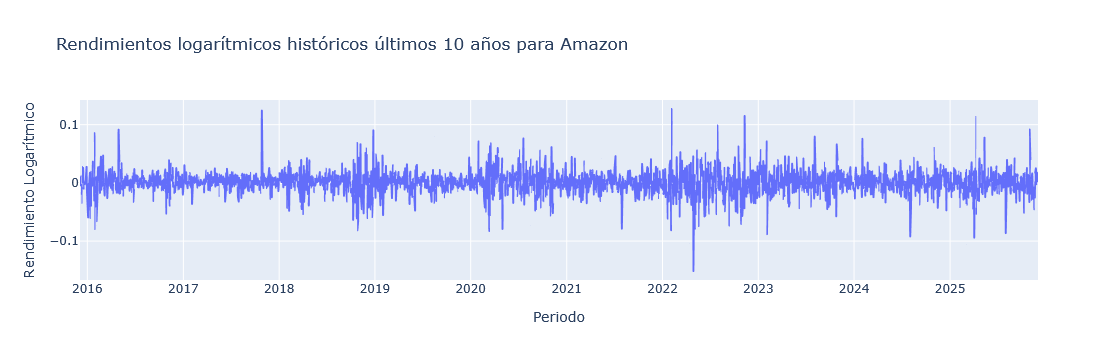

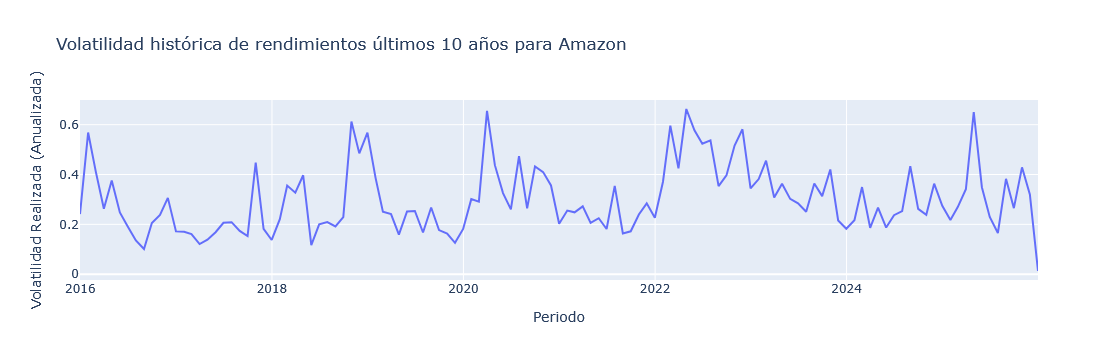

In [13]:
#1.Importar las librerías requeridas

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import pandas as pd 
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
from dateutil.relativedelta import relativedelta
#2. Variables de fechas
fecha_incial = datetime.now()- relativedelta(years=10)
fecha_fin   = datetime.now()
#3. Definir estilo del gráfico y control mensajes de advertencia 

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.dpi'] = 300
warnings.simplefilter(action='ignore', category=FutureWarning)

#4. Descargar los datos desdes Yahoo Finance 

df = yf.download('AMZN', 
                # start='2010-01-01', 
                # end='2020-11-30', 
                 start=fecha_incial.strftime('%Y-%m-%d'),
                 end=fecha_fin.strftime('%Y-%m-%d'),
                 auto_adjust=False,
                 progress=False)

# 5.Guardar solamente el precio de cierre ajustado

df = df.loc[:, ['Adj Close']]
df.rename(columns={'Adj Close': 'adj_close'}, inplace=True)

# 6.Calcular los rendimientos logarítmicos

df['log_rtn'] = np.log(df.adj_close/df.adj_close.shift(1))

#7. Eliminar datos redundantes

df.drop('adj_close', axis=1, inplace=True)
df.dropna(axis=0, inplace=True)


#8 Definir la función para calcular la volatilidad realizada


def realized_volatility(x):
    return np.sqrt(np.sum(x**2))

# 9.Calcular la volatilidad realizada mensual


df_rv = df.groupby(pd.Grouper(freq='M')).apply(realized_volatility)
df_rv.rename(columns={'log_rtn': 'rv'}, inplace=True)


#10. Anualizar los valores

df_rv.rv = df_rv.rv * np.sqrt(12)

# 11.Graficar los resultados

import plotly.express as px
# Gráfico Interactivo para Rendimientos Logarítmicos
fig_rtn = px.line(
    df,
    x=df.index,
    y='log_rtn',
    title='Rendimientos logarítmicos históricos últimos 10 años para Amazon',
    labels={'log_rtn': 'Rendimiento Logarítmico',  'Date': 'Periodo'}
)
fig_rtn.update_traces(hovertemplate='%{y:.4f}<extra></extra>') # Formato del tooltip
fig_rtn.show()

# Gráfico Interactivo para Volatilidad Realizada Mensual
fig_rv = px.line(
    df_rv,
    x=df_rv.index,
    y='rv',
    title='Volatilidad histórica de rendimientos últimos 10 años para Amazon',
    labels={'rv': 'Volatilidad Realizada (Anualizada)', 'Date': 'Periodo'}
)
fig_rv.update_traces(hovertemplate='%{y:.4f}<extra></extra>') # Formato del tooltip
fig_rv.show()